# Installing the package

Uncomment this line to download the package. For best results, install PyVaR in a fresh Python environment to avoid conflicts with existing packages.

In [1]:
#pip install git+https://github.com/Alessandro-Dodon/pyvar.git#subdirectory=package

---

## Notebook Overview

This notebook covers **analytic portfolio VaR**, the core of modern risk management. Unlike previous sections focused on single assets, we now shift to modeling **entire portfolios**, even if under simplifying assumptions.

This step is essential not just for **measuring** risk, but for actively **managing** it across assets. We compute portfolio VaR using the variance-covariance framework, assuming linear positions and Normal returns.

We begin with basic models assuming constant correlations and volatility, but these methods form the foundation for more advanced techniques used in practice.


### Packages

We begin by importing the `pyvar` package along with other necessary libraries for data handling, analysis, and visualization. Ensure all required packages are installed in your environment before proceeding.

In [2]:
import pyvar as pv

In [3]:
import pandas as pd

---

### Creating a Portfolio 

Our package provides simple functions to automatically build your portfolio: prices are downloaded from Yahoo Finance, you specify the number of shares, and optionally convert everything to your base currency (CHF in our case). Those are particularly useful to check common problems like missing values, stability of the VCV matrix etc.

Our example portfolio follows a stylized global equity strategy:  
- Long positions in broad market, regional, and sector ETFs (VT, SPY, VGK, EWJ, VWO)  
- Exposure to leading firms in tech, healthcare, and consumer sectors (AAPL, JNJ, PG, UNH, NVS)  
- A small short position in industrials (XLI) to hedge against cyclical downturns

We assume a **buy-and-hold** or "lazy portfolio" strategy. No active trading or rebalancing is considered. If the portfolio composition changes, all subsequent VaR and ES metrics must be recomputed from that point onward.

In [4]:
# Define shares — globally diversified portfolio
shares = pd.Series({
    "VT": 120,     # Global equity ETF
    "SPY": 80,     # US large-cap ETF
    "VGK": 60,     # Europe ETF
    "EWJ": 40,     # Japan ETF
    "VWO": 60,     # Emerging Markets ETF
    "AAPL": 50,    # Apple — tech
    "JNJ": 50,     # Johnson & Johnson — healthcare
    "PG": 40,      # Procter & Gamble — consumer staples
    "UNH": 40,     # UnitedHealth — healthcare
    "NVS": 30,     # Novartis — Swiss healthcare
    "XLI": -30     # US industrials sector ETF — short hedge
})

# Download prices and convert to base currency
tickers = shares.index.tolist()
raw_prices = pv.get_raw_prices(tickers, start="2023-01-01", end="2025-01-01")
prices_chf = pv.convert_to_base_currency(raw_prices, base_currency="CHF")

# Compute monetary position values over time
portfolio_matrix = pv.create_portfolio(prices_chf, shares)

# Compute portfolio returns and statistics
portfolio_returns = pv.compute_returns(portfolio_matrix)

[currency detection] AAPL: USD
[currency detection] EWJ: USD
[currency detection] JNJ: USD
[currency detection] NVS: USD
[currency detection] PG: USD
[currency detection] SPY: USD
[currency detection] UNH: USD
[currency detection] VGK: USD
[currency detection] VT: USD
[currency detection] VWO: USD
[currency detection] XLI: USD
[fx download] Downloading FX pairs: CHFUSD=X
[conversion] AAPL: USD → CHF via CHFUSD=X
[conversion] EWJ: USD → CHF via CHFUSD=X
[conversion] JNJ: USD → CHF via CHFUSD=X
[conversion] NVS: USD → CHF via CHFUSD=X
[conversion] PG: USD → CHF via CHFUSD=X
[conversion] SPY: USD → CHF via CHFUSD=X
[conversion] UNH: USD → CHF via CHFUSD=X
[conversion] VGK: USD → CHF via CHFUSD=X
[conversion] VT: USD → CHF via CHFUSD=X
[conversion] VWO: USD → CHF via CHFUSD=X
[conversion] XLI: USD → CHF via CHFUSD=X


In [5]:
prices_chf.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,231.426704,59.223917,128.896222,85.194986,149.932985,537.042054,449.589076,56.368561,106.685954,40.067612,119.804957
2024-12-26,232.407133,59.973532,128.793635,85.328432,151.175409,537.645712,454.555311,56.578238,106.923679,40.011430,120.021024
2024-12-27,229.196950,60.393619,128.250566,85.270424,150.528611,531.678524,453.261519,56.360245,106.023655,39.845030,119.058198
2024-12-30,226.896698,60.081229,127.153121,84.627656,148.847330,527.330344,452.791238,56.172810,105.341614,39.625007,118.246502
2024-12-31,225.645051,60.120737,128.487744,84.741616,149.578046,526.227574,451.761624,56.268884,105.263231,39.623541,118.286434


In [6]:
# Compute latest portfolio value and weights
latest_prices = prices_chf.iloc[-1]
portfolio_value_chf = (shares * latest_prices).sum()
weights = (shares * latest_prices) / portfolio_value_chf

# Print final portfolio value and weights
print(f"\nFinal portfolio value in CHF: {portfolio_value_chf:,.2f}\n")
print("Portfolio weights (based on latest prices):")
print(weights.round(4).sort_values(ascending=False))


Final portfolio value in CHF: 103,642.05

Portfolio weights (based on latest prices):
SPY     0.4062
UNH     0.1744
VT      0.1219
AAPL    0.1089
JNJ     0.0620
PG      0.0577
VGK     0.0326
NVS     0.0245
EWJ     0.0232
VWO     0.0229
XLI    -0.0342
dtype: float64


A quick way to observe the correlations of our portfolio!


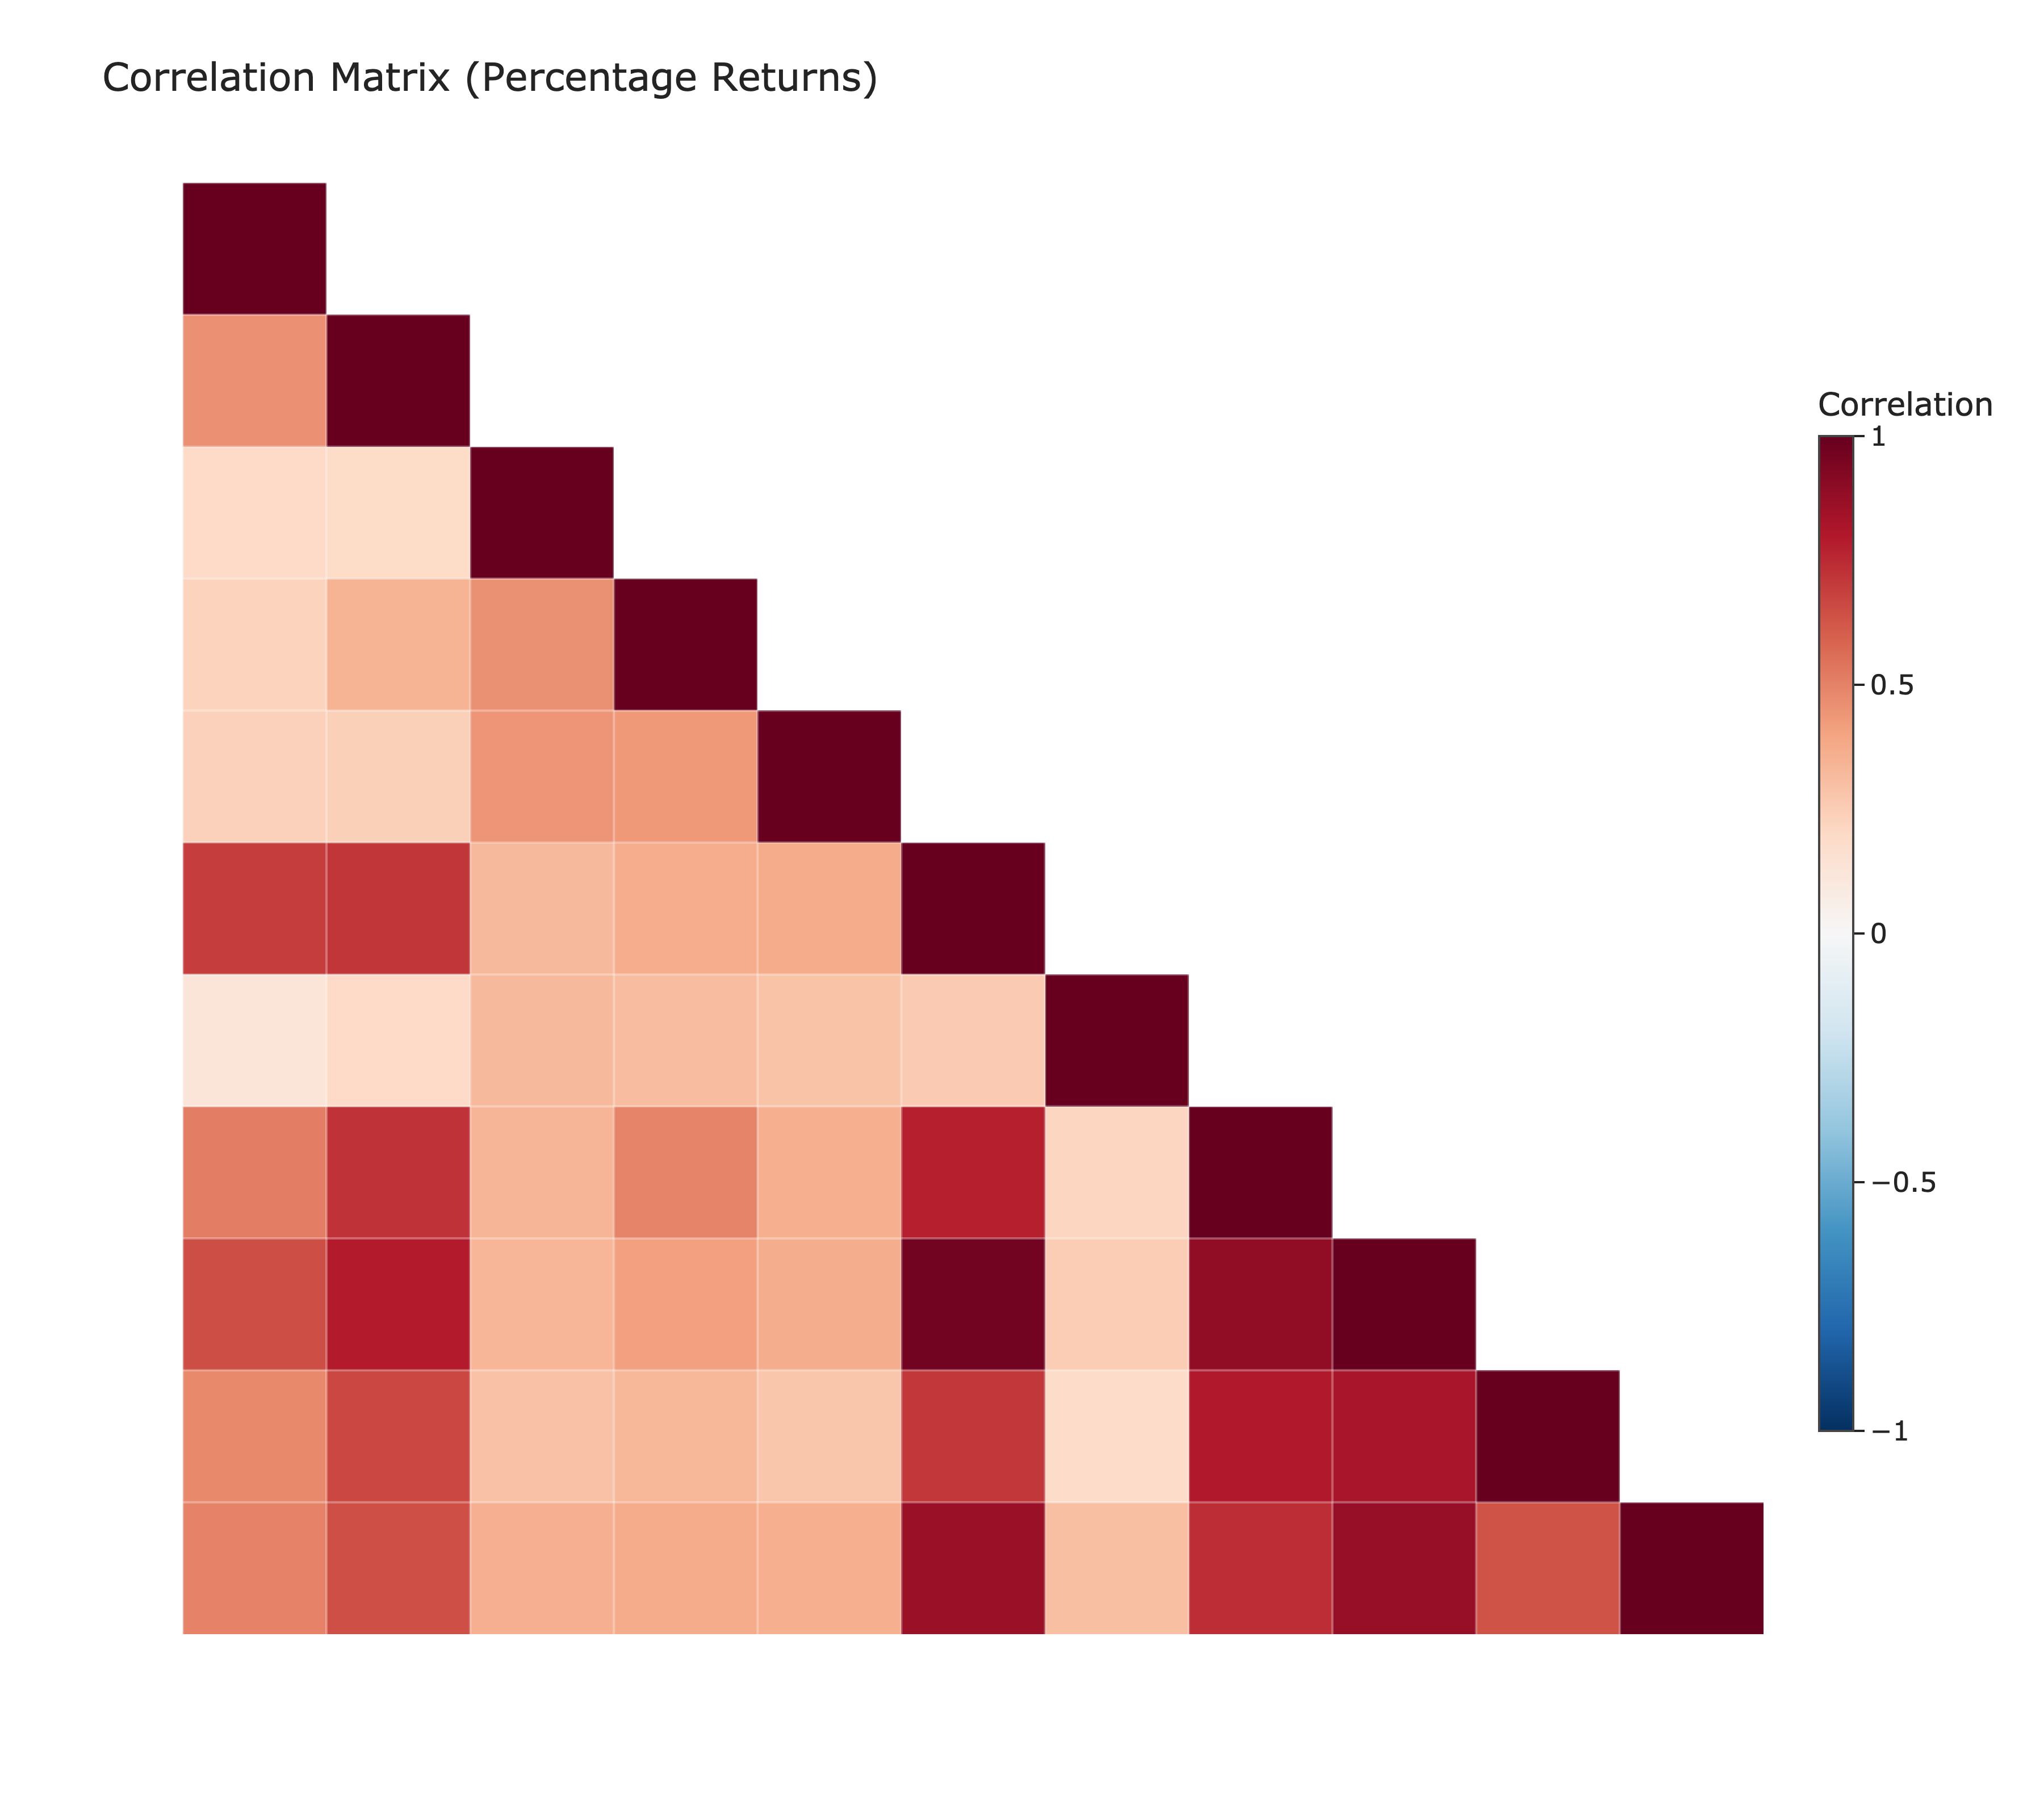

In [7]:
pv.plot_correlation_matrix(portfolio_matrix, interactive=False)

In [8]:
portfolio_matrix.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,11571.335187,2368.956681,6444.811080,2555.849567,5997.319403,42963.364293,17983.563021,3382.113663,12802.314449,2404.056728,-3594.148724
2024-12-26,11620.356641,2398.941292,6439.681748,2559.852947,6047.016349,43011.656968,18182.212443,3394.694253,12830.841531,2400.685826,-3600.630706
2024-12-27,11459.847524,2415.744774,6412.528308,2558.112730,6021.144452,42534.281923,18130.460765,3381.614726,12722.838569,2390.701805,-3571.745932
2024-12-30,11344.834895,2403.249158,6357.656070,2538.829686,5953.893188,42186.427518,18111.649528,3370.368576,12640.993732,2377.500427,-3547.395061
2024-12-31,11282.252544,2404.829490,6424.387178,2542.248472,5983.121833,42098.205949,18070.464940,3376.133050,12631.587685,2377.412469,-3548.593034


In [9]:
portfolio_returns.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,0.017617,0.005464,0.010086,0.005047,0.011036,0.017252,0.005592,0.011608,0.014032,0.010130,0.013929
2024-12-26,0.004236,0.012657,-0.000796,0.001566,0.008287,0.001124,0.011046,0.003720,0.002228,-0.001402,0.001803
2024-12-27,-0.013813,0.007005,-0.004217,-0.000680,-0.004278,-0.011099,-0.002846,-0.003853,-0.008417,-0.004159,-0.008022
2024-12-30,-0.010036,-0.005173,-0.008557,-0.007538,-0.011169,-0.008178,-0.001038,-0.003326,-0.006433,-0.005522,-0.006818
2024-12-31,-0.005516,0.000658,0.010496,0.001347,0.004909,-0.002091,-0.002274,0.001710,-0.000744,-0.000037,0.000338


If you want to **save the DataFrame shown above**, use:

```python
portfolio_returns.to_csv("portfolio_returns.csv")
```

If you want to **import your own CSV**, make sure the first column contains dates and use:

```python
df = pd.read_csv("your_file.csv", index_col=0, parse_dates=True)
```

This ensures:
- The first column becomes the date index
- Dates are properly parsed for the analysis

Note: You are responsible for data cleaning and pre-processing when using your own files. Our data-download functions will print warnings if there are issues, but they do not perform automatic cleaning.

---

### Asset-Normal VaR and Undiversified VaR

We now cover two classic portfolio-level VaR measures that help assess total and undiversified risk over time. Each provides a different perspective on portfolio exposure and diversification:

- **Asset-Normal VaR (AN VaR)** estimates total portfolio risk under the assumption of joint Normality and full correlation structure. It accounts for asset interactions via the covariance matrix $\Sigma$:
  $$
  \text{VaR}_t = z_\alpha \cdot \sqrt{x_t^\top \Sigma x_t} \cdot \sqrt{h}
  $$

- **Undiversified VaR (UVaR)** assumes no diversification benefit — i.e., all assets are uncorrelated — and simply sums the marginal risks from each asset:
  $$
  \text{UVaR}_t = z_\alpha \cdot \sum_{i=1}^N \sigma_i x_{i,t} \cdot \sqrt{h}
  $$

Here:
- $x_t$ are the monetary positions,
- $\Sigma$ is the covariance matrix of asset returns,
- $\sigma_i$ are individual asset volatilities,
- $z_\alpha$ is the Normal quantile (e.g., 2.33 for 99%),
- $h$ is the horizon in days.

By comparing these two metrics over time, we can evaluate the contribution of diversification and track changes in portfolio risk dynamics.


In [ ]:
# General parameter
confidence_level = 0.99

In [11]:
# Compute and display the AN VaR   
asset_normal_results = pv.asset_normal_var(position_data=portfolio_matrix,
                                 confidence_level=confidence_level)


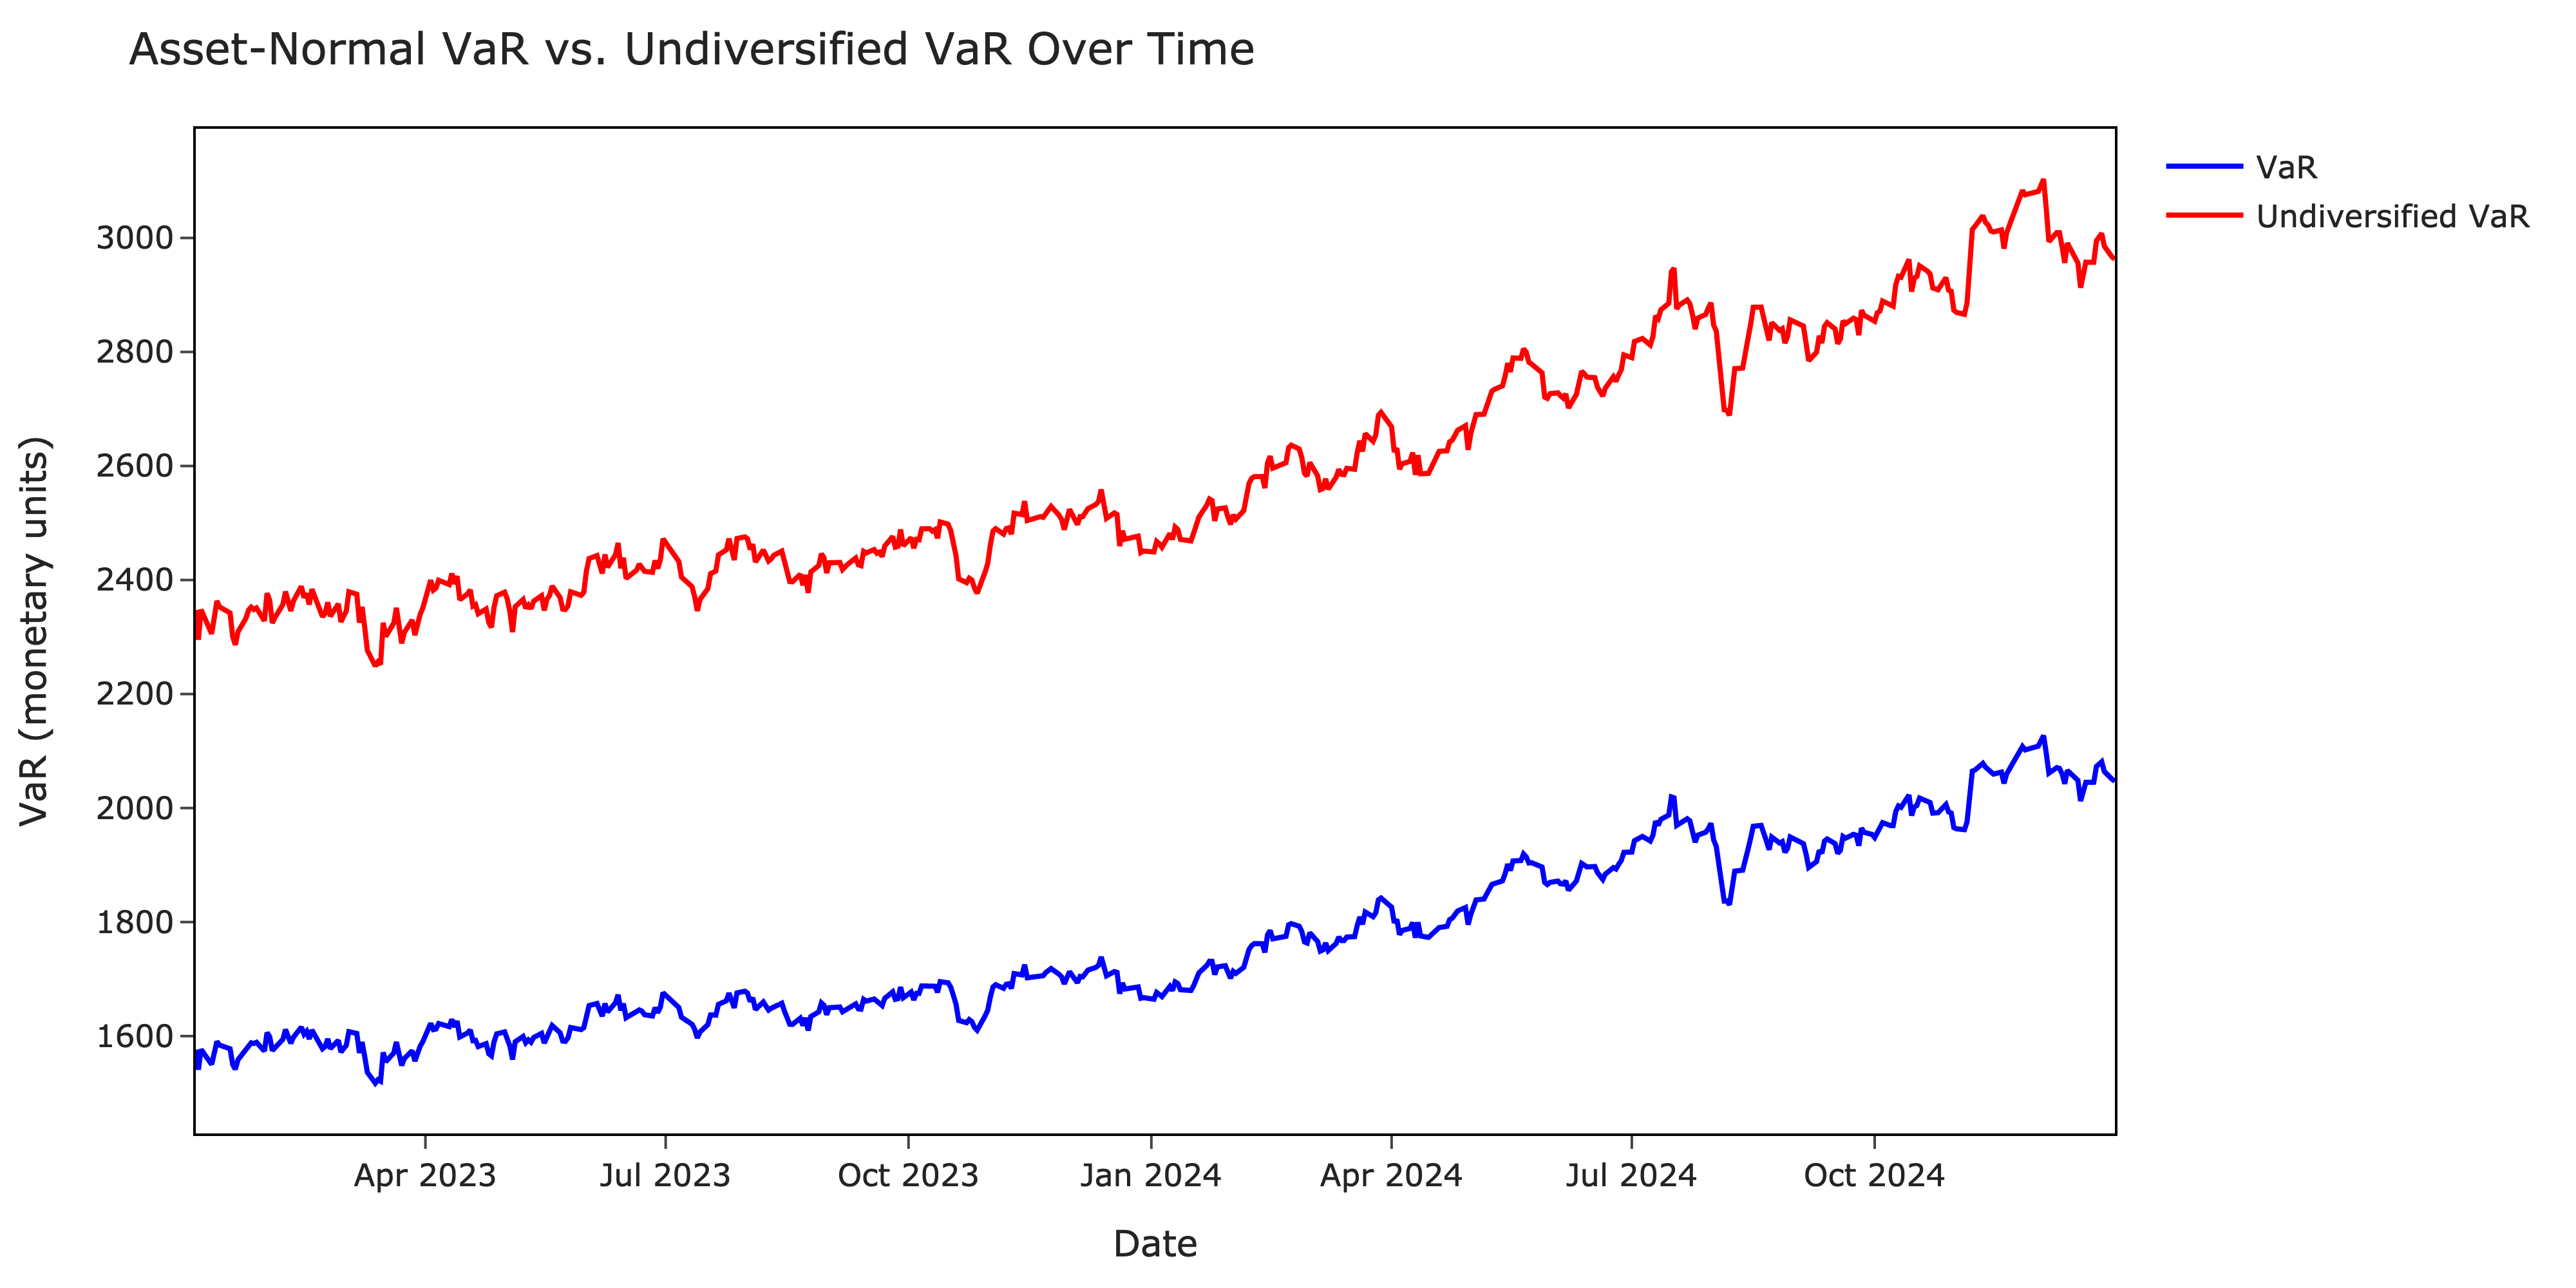

In [ ]:
# Plot the AN VaR results
pv.plot_var_vs_uvar(asset_normal_results, interactive=False)

In [13]:
asset_normal_results.head()

,Diversified_VaR,Undiversified_VaR,Diversification_Benefit
Date,,,
2023-01-04,1576.259552,2347.466347,771.206794
2023-01-05,1540.972475,2295.059604,754.087130
2023-01-06,1576.589772,2348.108696,771.518924
2023-01-09,1558.538315,2318.830614,760.292299
2023-01-10,1550.268071,2305.615409,755.347338


---

### Component VaR

We now proceed with **Component VaR**, which breaks down the total portfolio VaR into the contribution of each asset. This allows us to see how individual positions drive overall risk.

First, we define the **Marginal VaR** — the sensitivity of portfolio VaR to a change in the position of asset $i$:

$$
\Delta \text{VaR}_{i,t} = \text{VaR}_t \cdot \frac{(\Sigma x_t)_i}{x_t^\top \Sigma x_t}
$$

Then, **Component VaR** is computed by scaling the marginal risk by the monetary position:

$$
\text{CVaR}_{i,t} = x_{i,t} \cdot \Delta \text{VaR}_{i,t}
$$

These measures help identify **which assets contribute most to portfolio risk**, making them valuable for **risk budgeting, monitoring**, and **optimization**.

Note: Each of these metrics can be computed independently — the functions are modular and automatically call dependencies where needed.


In [14]:
# Compute and display Component VaR (styled table)
component_df = pv.component_var(
    position_data=portfolio_matrix,
    confidence_level=confidence_level
)


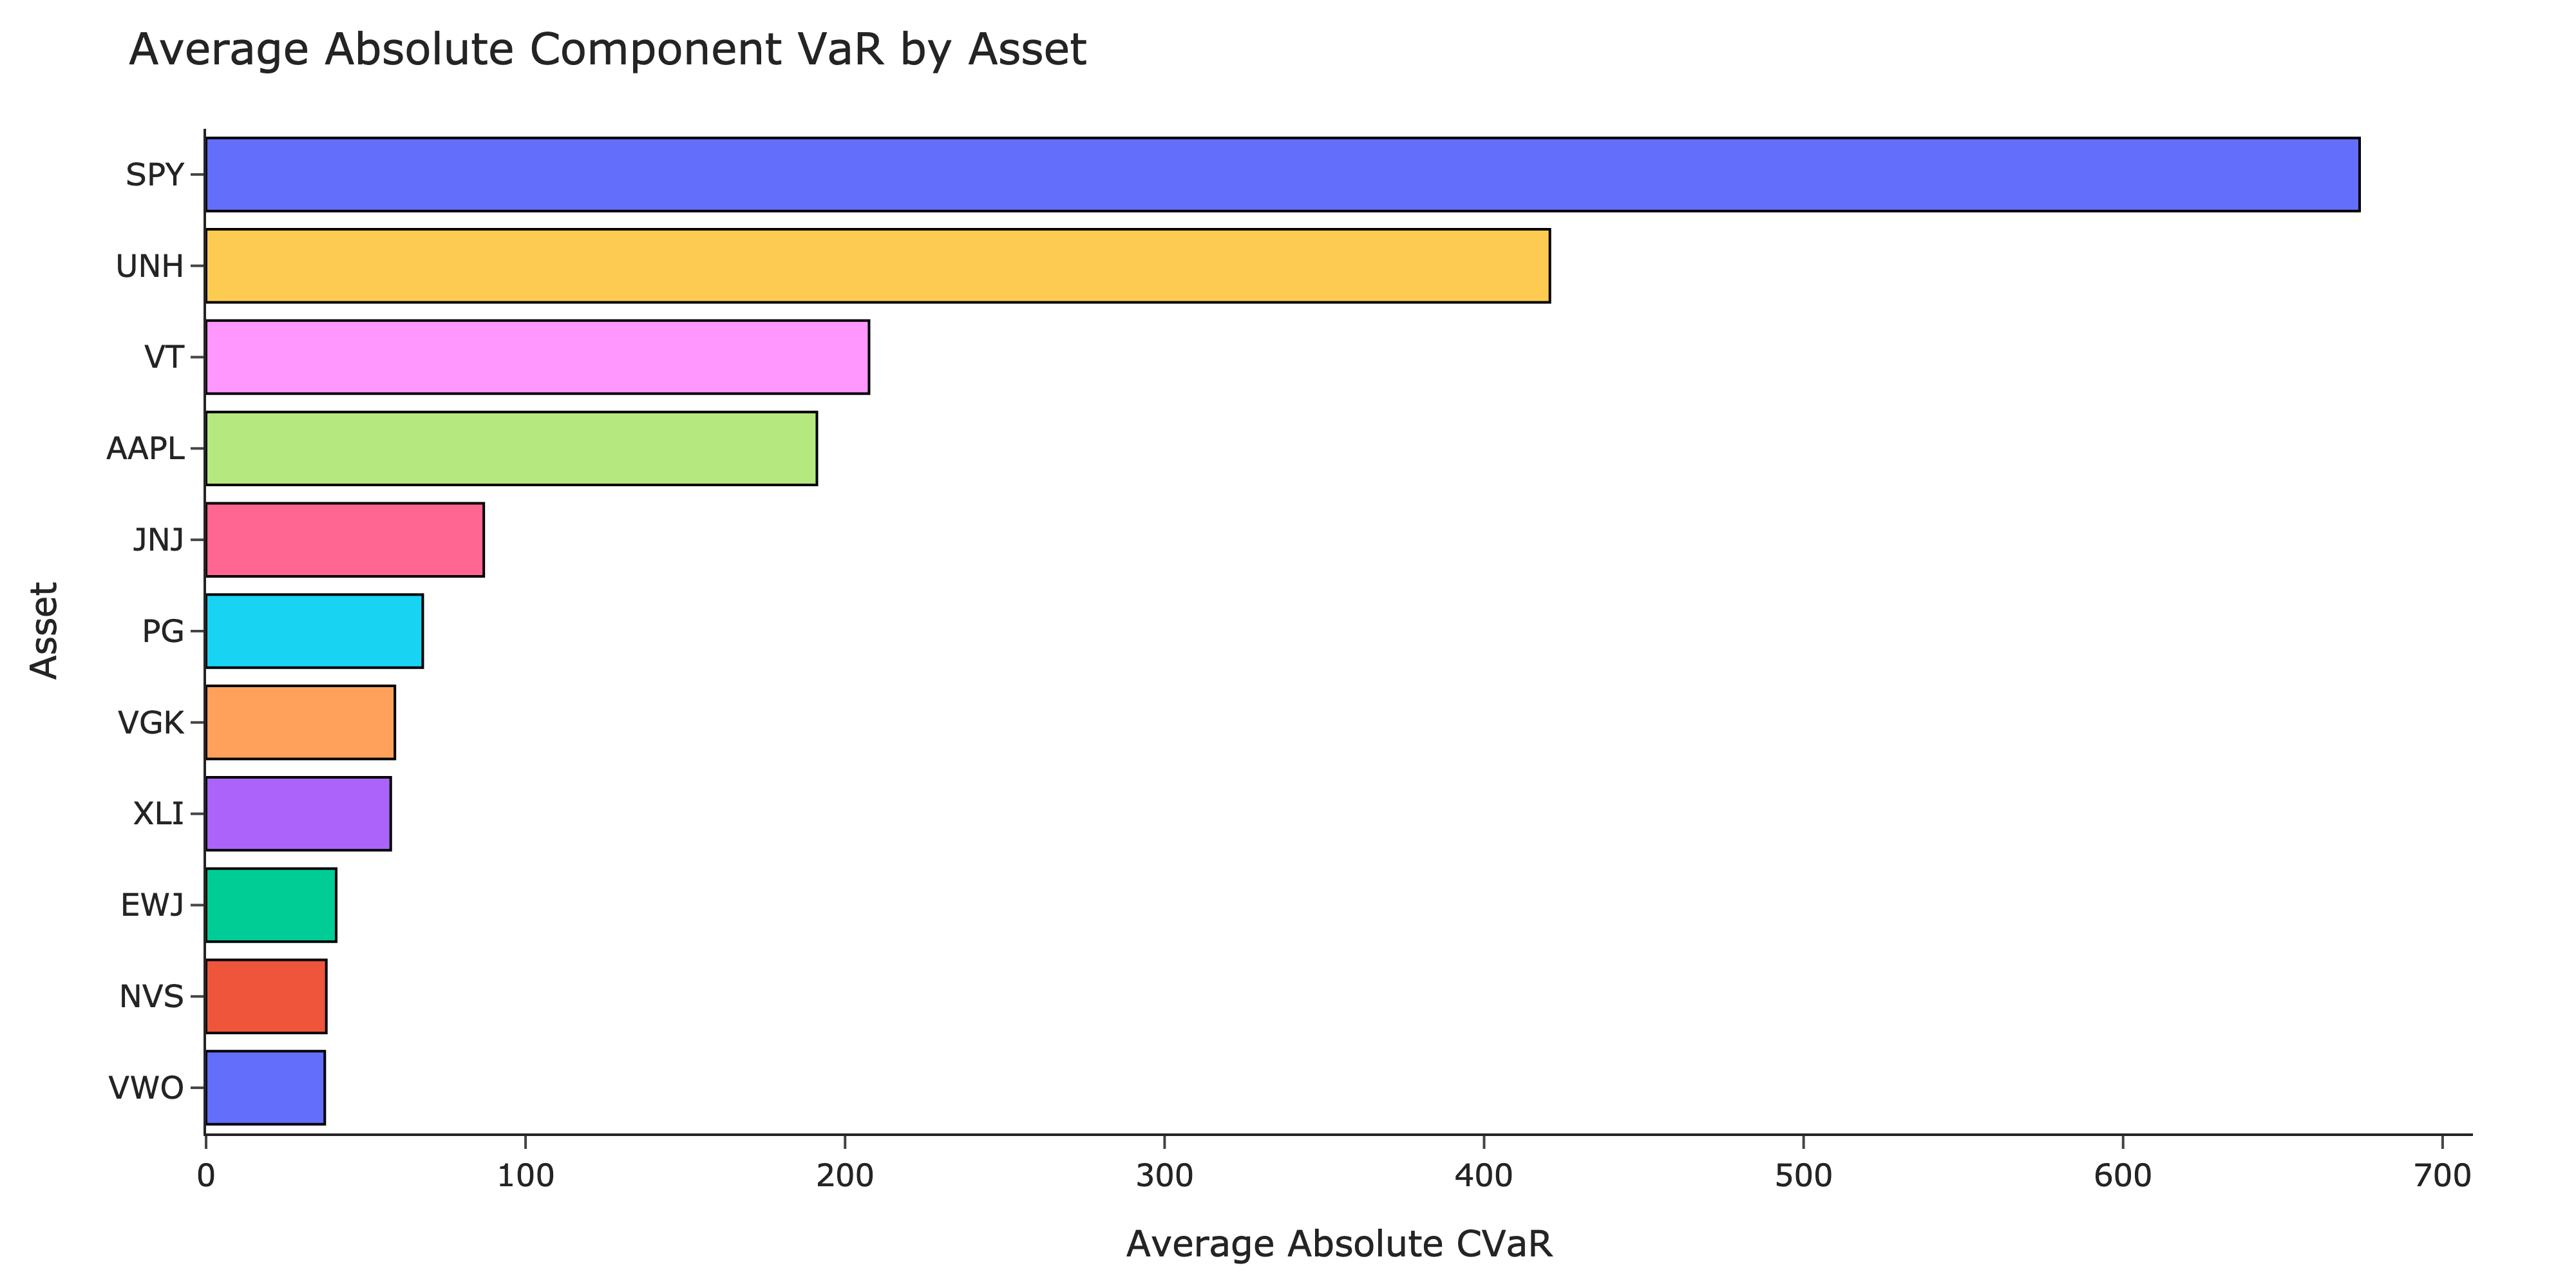

In [ ]:
# Plot the Component VaR results
pv.plot_component_var_bar(component_df, interactive=False)


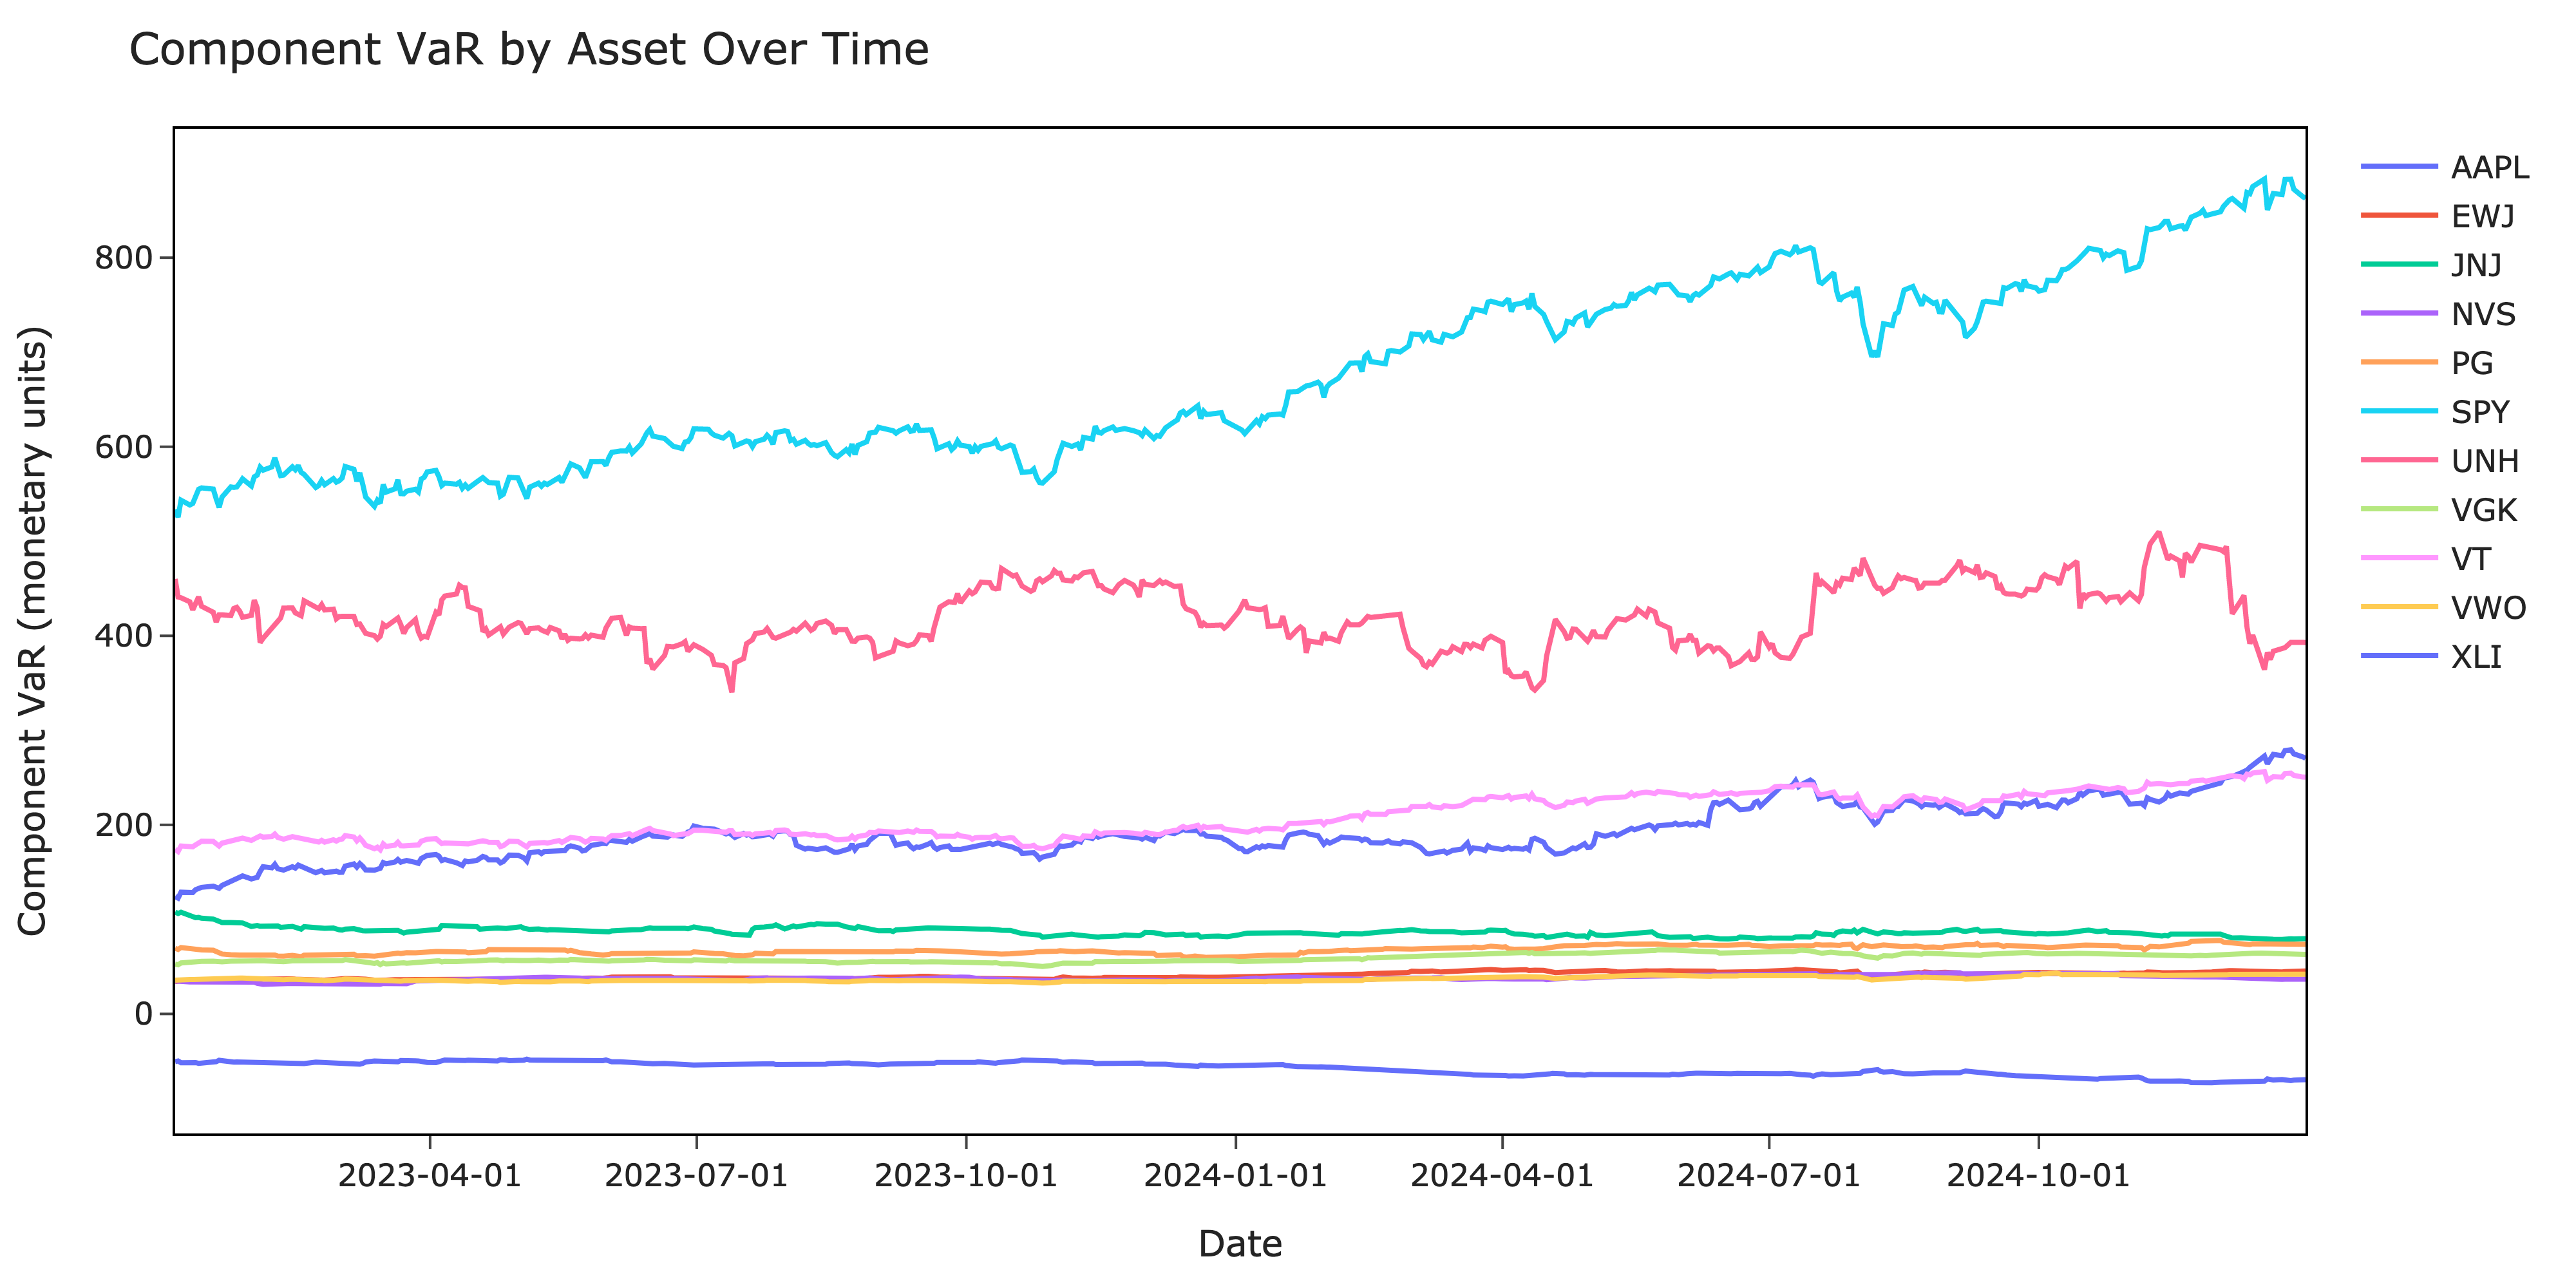

In [ ]:
# Plot the Component VaR results over time
pv.plot_component_var_lines(component_df, interactive=False)

In [17]:
component_df.head()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2023-01-04,124.205983,34.297420,107.622804,34.935889,69.387350,533.648590,460.142734,52.623463,174.292755,35.641967,-50.539402
2023-01-05,122.520018,33.706328,106.232075,34.336941,68.134043,525.550103,441.033289,51.957428,171.857753,35.416046,-49.771548
2023-01-06,128.723219,34.925752,107.555607,35.116700,70.245985,543.420854,440.220227,53.903533,177.689336,36.408213,-51.619654
2023-01-09,128.217462,34.712475,103.221282,33.799952,68.521989,538.416770,435.965923,53.756505,176.567215,36.286058,-50.927316
2023-01-10,128.345730,34.487995,102.190946,33.760905,67.988303,540.013493,427.455584,53.788573,176.809890,36.395442,-50.968789


---

### Incremental VaR

We conclude the in-depth portfolio analytics with **Incremental VaR**, which measures how the total portfolio VaR changes when a new position is added or removed.

It is defined as:

$$
\text{IVaR}_t = \Delta \text{VaR}_t^\top \cdot a
$$

Here, $a$ is the vector of changes in asset positions, and $\Delta \text{VaR}_t$ is the Marginal VaR vector at time $t$.

Incremental VaR is useful for **what-if analysis**, allowing you to assess the impact of portfolio adjustments on overall risk before implementing them.

This module also includes the corresponding **Incremental ES** measures — feel free to experiment with both to gain deeper insights into portfolio risk behavior.


In [18]:
# Define change in position
change_vector = [0,10_000,0,0,0,0,0,0,0,0,0] # 10K CHF in SPY

# Compute and display Incremental VaR
ivar_series = pv.incremental_var(
    position_data=portfolio_matrix,
    change_vector=change_vector,
    confidence_level=confidence_level
)

In [19]:
ivar_series

Date
2023-01-04    178.156938
2023-01-05    178.664327
2023-01-06    179.394467
2023-01-09    179.629034
2023-01-10    180.044922
                 ...    
2024-12-24    188.774408
2024-12-26    188.646308
2024-12-27    188.588098
2024-12-30    188.505409
2024-12-31    188.490294
Length: 501, dtype: float64